In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("final_adult_cleaned.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (19051, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,38,private,215646,hs-grad,9,divorced,handlers-cleaners,not-in-family,white,male,0,0,40,united states,<=50k
1,53,private,234721,11th,7,married-civ-spouse,handlers-cleaners,husband,black,male,0,0,40,united states,<=50k
2,28,private,338409,bachelors,13,married-civ-spouse,prof-specialty,wife,black,female,0,0,40,cuba,<=50k
3,37,private,284582,masters,14,married-civ-spouse,exec-managerial,wife,white,female,0,0,40,united states,<=50k
4,52,self-emp-not-inc,209642,hs-grad,9,married-civ-spouse,exec-managerial,husband,white,male,0,0,45,united states,>50k


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19051 entries, 0 to 19050
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             19051 non-null  int64 
 1   workclass       19051 non-null  object
 2   fnlwgt          19051 non-null  int64 
 3   education       19051 non-null  object
 4   education_num   19051 non-null  int64 
 5   marital_status  19051 non-null  object
 6   occupation      19051 non-null  object
 7   relationship    19051 non-null  object
 8   race            19051 non-null  object
 9   sex             19051 non-null  object
 10  capital_gain    19051 non-null  int64 
 11  capital_loss    19051 non-null  int64 
 12  hours_per_week  19051 non-null  int64 
 13  native_country  19051 non-null  object
 14  income          19051 non-null  object
dtypes: int64(6), object(9)
memory usage: 2.2+ MB


In [24]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,19051.000000,1.905100e+04,19051.000000,19051.0,19051.0,19051.000000
mean,38.121411,1.917197e+05,10.064301,0.0,0.0,41.493937
std,11.811877,1.060898e+05,2.394945,0.0,0.0,3.956748
min,17.000000,1.487800e+04,3.000000,0.0,0.0,33.000000
25%,28.000000,1.187930e+05,9.000000,0.0,0.0,40.000000
50%,37.000000,1.803090e+05,10.000000,0.0,0.0,40.000000
75%,47.000000,2.389590e+05,12.000000,0.0,0.0,41.000000
max,75.000000,1.455435e+06,16.000000,0.0,0.0,52.000000


In [25]:
df["income_numeric"] = df["income"].map({"<=50k":0, ">50k":1})

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_numeric
0,38,private,215646,hs-grad,9,divorced,handlers-cleaners,not-in-family,white,male,0,0,40,united states,<=50k,0
1,53,private,234721,11th,7,married-civ-spouse,handlers-cleaners,husband,black,male,0,0,40,united states,<=50k,0
2,28,private,338409,bachelors,13,married-civ-spouse,prof-specialty,wife,black,female,0,0,40,cuba,<=50k,0
3,37,private,284582,masters,14,married-civ-spouse,exec-managerial,wife,white,female,0,0,40,united states,<=50k,0
4,52,self-emp-not-inc,209642,hs-grad,9,married-civ-spouse,exec-managerial,husband,white,male,0,0,45,united states,>50k,1


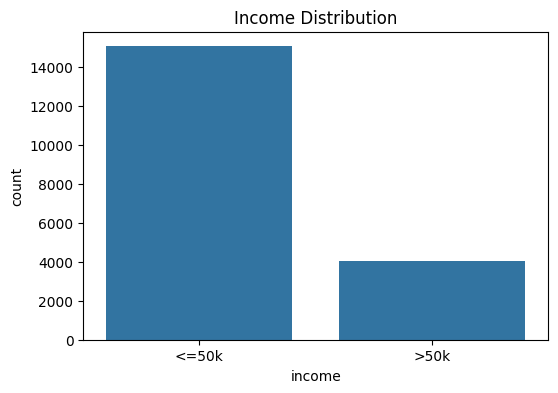

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x="income", data=df)

plt.title("Income Distribution")

plt.show()

In [27]:
income_percentage = df["income"].value_counts(normalize=True) * 100

print("Income percentage distribution:\n")

print(income_percentage)

Income percentage distribution:

income
<=50k    78.903995
>50k     21.096005
Name: proportion, dtype: float64


In [28]:
df.groupby("income")["hours_per_week"].mean()

income
<=50k    41.13744
>50k     42.82732
Name: hours_per_week, dtype: float64

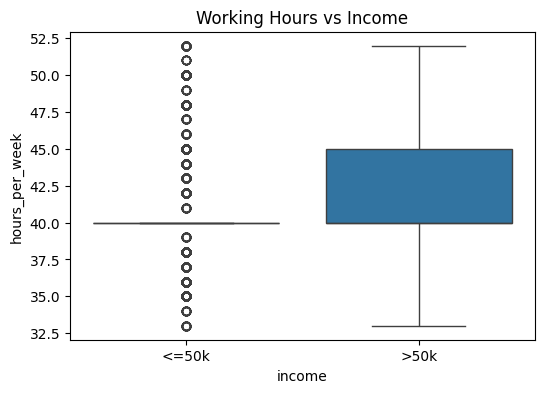

In [29]:
plt.figure(figsize=(6,4))

sns.boxplot(x="income", y="hours_per_week", data=df)

plt.title("Working Hours vs Income")

plt.show()

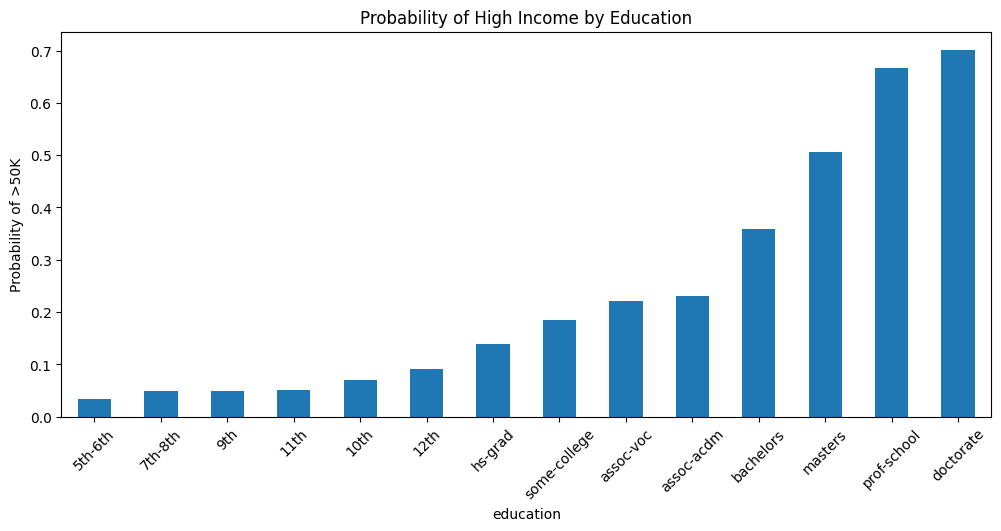

In [30]:
education_income = df.groupby("education")["income_numeric"].mean().sort_values()

plt.figure(figsize=(12,5))

education_income.plot(kind="bar")

plt.title("Probability of High Income by Education")

plt.ylabel("Probability of >50K")

plt.xticks(rotation=45)

plt.show()

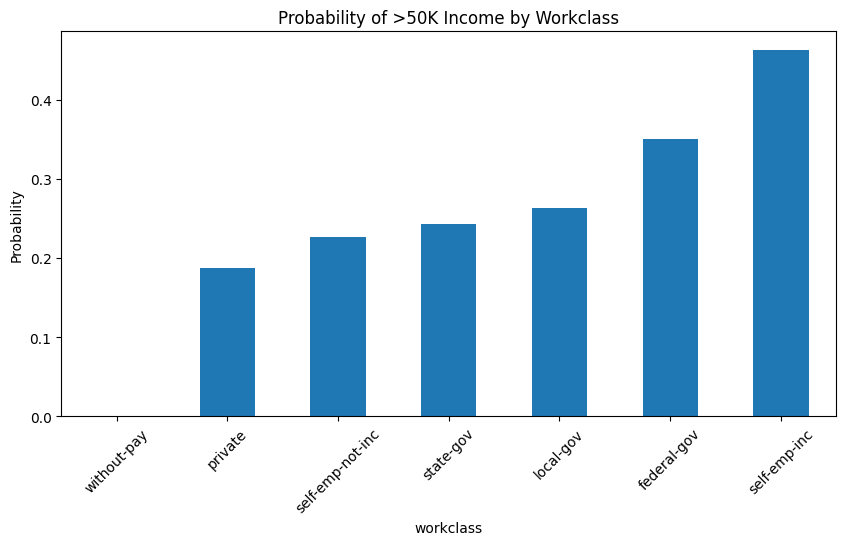

In [31]:
workclass_income = df.groupby("workclass")["income_numeric"].mean().sort_values()

plt.figure(figsize=(10,5))

workclass_income.plot(kind="bar")

plt.title("Probability of >50K Income by Workclass")

plt.ylabel("Probability")

plt.xticks(rotation=45)

plt.show()

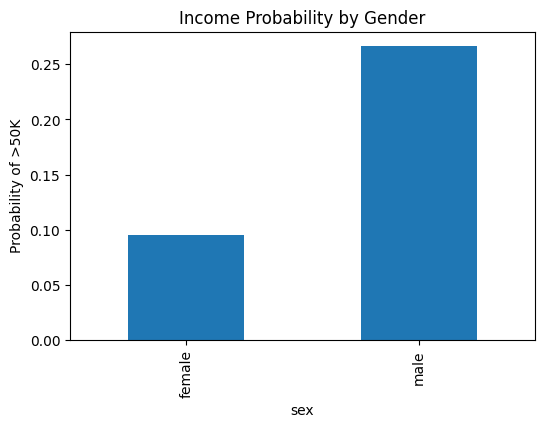

In [32]:
gender_income = df.groupby("sex")["income_numeric"].mean()

plt.figure(figsize=(6,4))

gender_income.plot(kind="bar")

plt.title("Income Probability by Gender")

plt.ylabel("Probability of >50K")

plt.show()

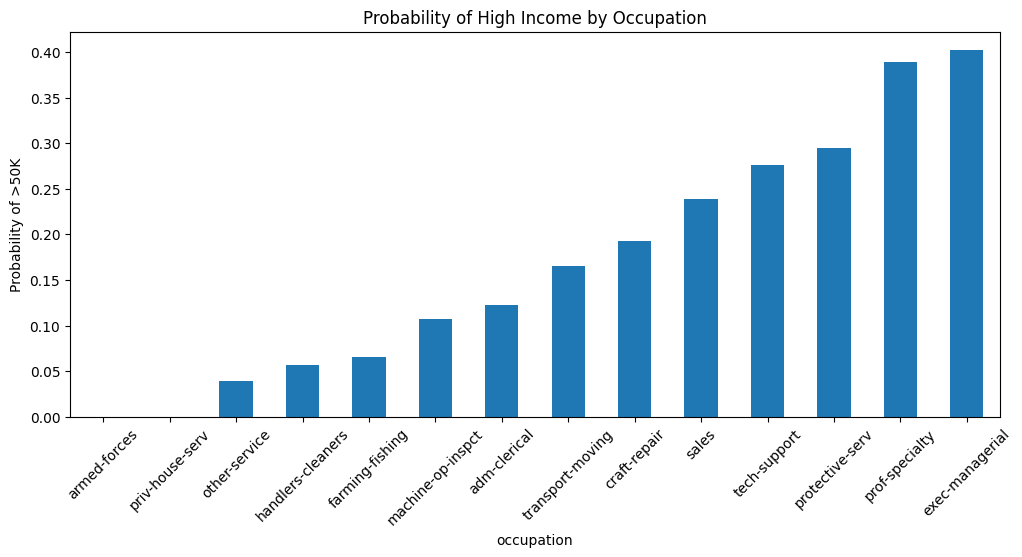

In [33]:
occupation_income = df.groupby("occupation")["income_numeric"].mean().sort_values()

plt.figure(figsize=(12,5))

occupation_income.plot(kind="bar")

plt.title("Probability of High Income by Occupation")

plt.ylabel("Probability of >50K")

plt.xticks(rotation=45)

plt.show()

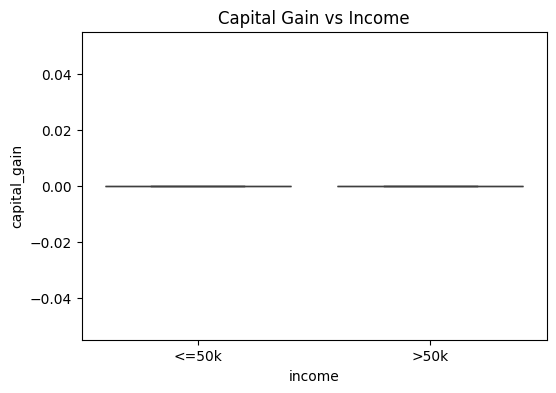

In [34]:
plt.figure(figsize=(6,4))

sns.boxplot(x="income", y="capital_gain", data=df)

plt.title("Capital Gain vs Income")

plt.show()

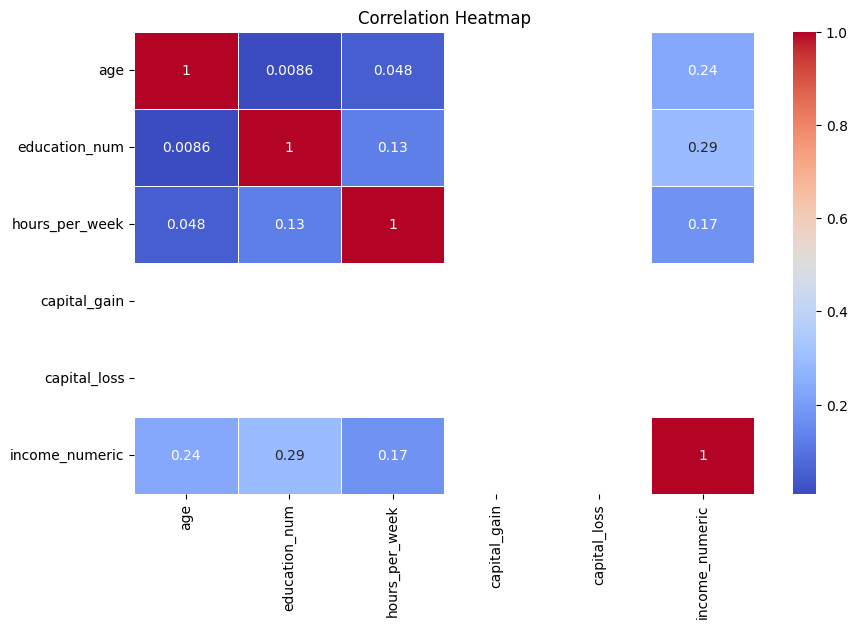

In [35]:
numeric_cols = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain",
    "capital_loss",
    "income_numeric"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

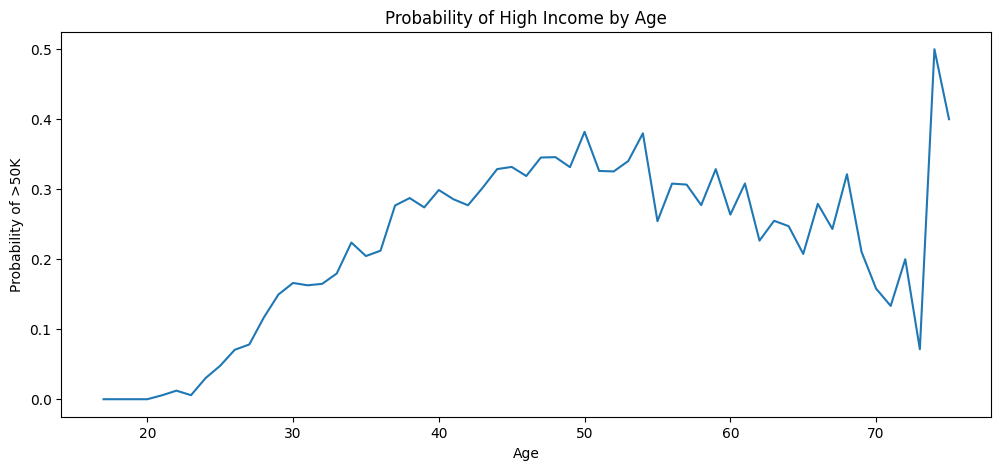

In [36]:
age_income = df.groupby("age")["income_numeric"].mean()

plt.figure(figsize=(12,5))

sns.lineplot(x=age_income.index, y=age_income.values)

plt.title("Probability of High Income by Age")

plt.xlabel("Age")

plt.ylabel("Probability of >50K")

plt.show()

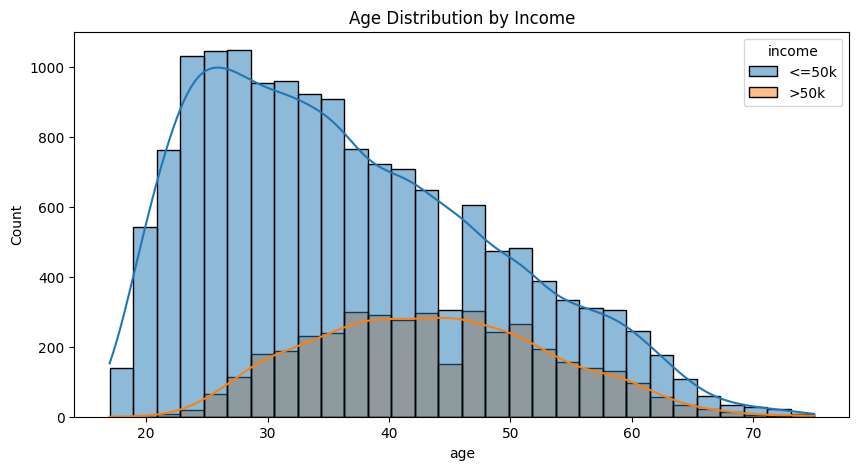

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x="age", hue="income", bins=30, kde=True)

plt.title("Age Distribution by Income")

plt.show()

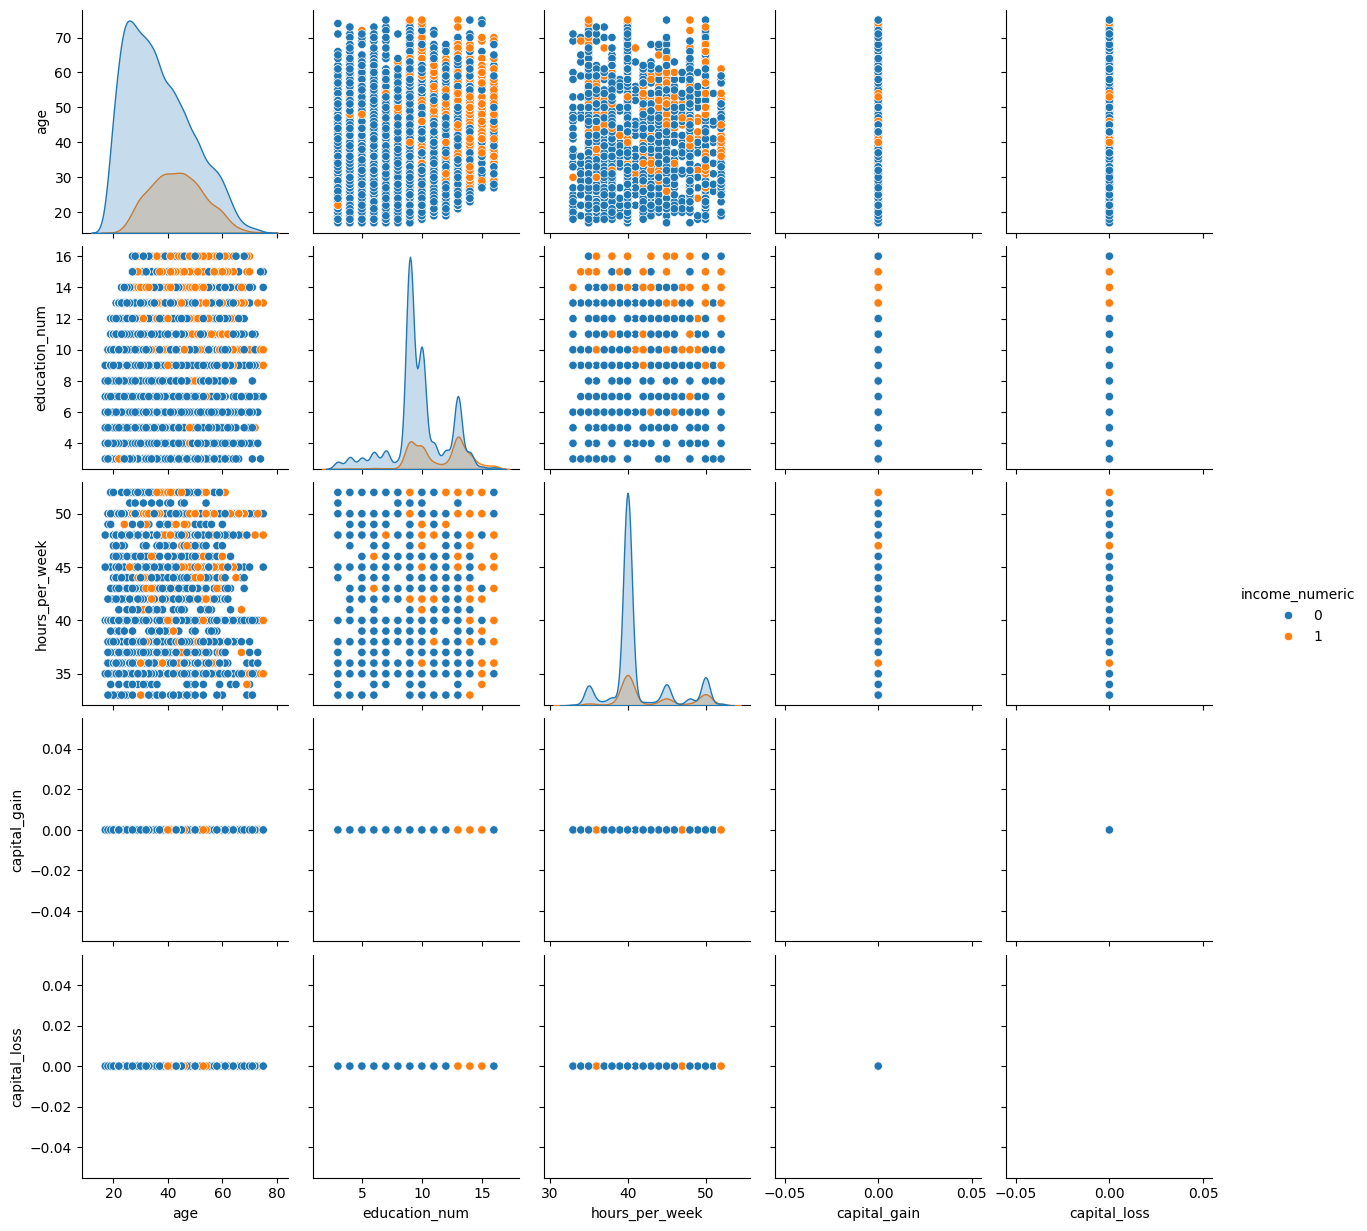

In [38]:
numeric_features = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain",
    "capital_loss",
    "income_numeric"
]

sns.pairplot(df[numeric_features], hue="income_numeric")

plt.show()

In [39]:
print("Key Insights:")

print("1. Higher education increases the probability of earning >50K.")

print("2. Individuals working more hours per week tend to earn higher income.")

print("3. Capital gain strongly correlates with high income.")

print("4. Age group around 35–50 shows higher earning potential.")

print("5. Occupation and workclass influence income levels.")

Key Insights:
1. Higher education increases the probability of earning >50K.
2. Individuals working more hours per week tend to earn higher income.
3. Capital gain strongly correlates with high income.
4. Age group around 35–50 shows higher earning potential.
5. Occupation and workclass influence income levels.
